# Waste Type Identification — 5-fold Cross-Validation (baseline ResNet18)

Obiettivo: capire se la Balanced Accuracy di validation (0.967) è **stabile** o frutto del caso
di un singolo split. Addestriamo la **stessa identica ricetta** della baseline su 5 fold e
guardiamo media e deviazione standard.

1. ogni fold viene addestrato dentro una funzione e a fine fold si **libera la RAM/GPU**
   (`gc.collect()` + `torch.cuda.empty_cache()`): così i 5 fold non si accumulano in memoria;
2. dopo ogni fold i risultati vengono **salvati su disco** (`results/cv_folds.csv`): se la
   sessione cade, i fold già fatti NON si perdono;
3. con `RESUME = True` il notebook **riprende dai fold mancanti**, saltando quelli già salvati.

Nota: questa CV misura la stabilità della stima **in-distribution**. Non sostituisce
la valutazione *out-of-distribution* su RealWaste (metrica guida per il test privato). Una
deviazione standard piccola qui significa che 0.967 è reale (saturazione), non fortuna.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path

BASE              = Path('/content/drive/MyDrive/2026_MLinf_gr41/Waste-Project')
DRIVE_DATASET_DIR = BASE / 'dataset'
DATASET_DIR       = Path('/content/dataset_local')                              # copia locale veloce
SPLIT_CV_CSV      = BASE / 'splits' / 'split_cv.csv'                            # CSV con la colonna 'fold' (1..5)
RESULTS_DIR       = BASE / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Iperparametri
IMG_SIZE     = 224
BATCH_SIZE   = 64
NUM_EPOCHS   = 15
LR           = 0.01
MOMENTUM     = 0.9
WEIGHT_DECAY = 1e-4
NUM_CLASSES  = 8
SEED         = 1234
K            = 5

FOLDS_TO_RUN = [1, 2, 3, 4, 5]
RESUME       = True

Mounted at /content/drive


In [ ]:
import random, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import balanced_accuracy_score, recall_score

def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [ ]:
# Copia del dataset in locale
import shutil, time
if not DATASET_DIR.exists():
    print('Copio il dataset in locale, attendi qualche minuto...')
    t0 = time.time()
    shutil.copytree(DRIVE_DATASET_DIR, DATASET_DIR)
    print(f'Copia completata in {time.time() - t0:.0f}s')
else:
    print('Copia locale gia presente:', DATASET_DIR)

Copio il dataset in locale, attendi qualche minuto...
Copia completata in 431s


In [ ]:
CLASS_NAMES   = ['battery','clothing','glass','metal','organic','papery','plastic','undifferentiated']
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Stessa trasformazione della baseline
tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class WasteDatasetCV(Dataset):
    def __init__(self, csv_path, dataset_dir, folds, transform):
        df = pd.read_csv(csv_path)
        self.df = df[df['fold'].isin(folds)].reset_index(drop=True)             # tiene solo i fold richiesti
        self.dataset_dir = Path(dataset_dir)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(self.dataset_dir / row['filepath']).convert('RGB')
        return self.transform(img), int(row['label'])


In [ ]:
# Modello e ciclo di un'epoca

def build_model(num_classes=NUM_CLASSES):
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

def run_epoch(model, loader, criterion, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in tqdm(loader, desc='train' if train else 'val', leave=False):
            x, y = x.to(device), y.to(device)
            out  = model(x)
            loss = criterion(out, y)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * x.size(0)
            all_preds.append(out.argmax(1).cpu())
            all_labels.append(y.cpu())
    preds  = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    return total_loss / len(loader.dataset), balanced_accuracy_score(labels, preds), preds, labels

In [ ]:
# Salvataggio/ripresa dei risultati per fold, per non perdere progressi

FOLDS_CSV = RESULTS_DIR / 'cv_folds.csv'

def save_folds(balacc, tpr):
    rows = []
    for f in sorted(balacc):
        row = {'fold': f, 'val_balanced_accuracy': balacc[f]}
        for i, name in enumerate(CLASS_NAMES):
            row[f'tpr_{name}'] = float(tpr[f][i])
        rows.append(row)
    pd.DataFrame(rows).to_csv(FOLDS_CSV, index=False)

def load_folds():
    balacc, tpr = {}, {}
    if FOLDS_CSV.exists():
        df = pd.read_csv(FOLDS_CSV)
        for _, r in df.iterrows():
            f = int(r['fold'])
            balacc[f] = float(r['val_balanced_accuracy'])
            tpr[f]    = np.array([r[f'tpr_{name}'] for name in CLASS_NAMES])
    return balacc, tpr

# Addestramento di un fold
def train_one_fold(f):
    print(f"\n========== FOLD {f}/{K} ==========")
    set_seed(SEED)                                                              # stessa inizializzazione, confronto equo

    train_folds = [k for k in range(1, K + 1) if k != f]                        # gli altri 4 fold sono il training
    train_ds = WasteDatasetCV(SPLIT_CV_CSV, DATASET_DIR, train_folds, tf)
    val_ds   = WasteDatasetCV(SPLIT_CV_CSV, DATASET_DIR, [f],         tf)
    print(f"Train: {len(train_ds)}  Val (fold {f}): {len(val_ds)}")

    # pin_memory=False per tenere bassa la RAM di sistema
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=False)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=False)

    model     = build_model().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    best_bal, best_tpr = 0.0, None
    for epoch in range(1, NUM_EPOCHS + 1):
        run_epoch(model, train_loader, criterion, optimizer, train=True)
        _, vl_bal, preds, labels = run_epoch(model, val_loader, criterion, train=False)
        scheduler.step()
        if vl_bal > best_bal:
            best_bal = vl_bal
            best_tpr = recall_score(labels, preds, average=None,
                                    labels=list(range(NUM_CLASSES)), zero_division=0)
        print(f"  epoch {epoch:02d} | val balAcc {vl_bal:.3f}")

    print(f"  >> FOLD {f}: best val balanced accuracy = {best_bal:.3f}")
    return best_bal, best_tpr

In [ ]:
# Ciclo sui fold con ripresa e pulizia memoria

all_fold_balacc, all_fold_tpr = ({}, {})
if RESUME:
    all_fold_balacc, all_fold_tpr = load_folds()
    if all_fold_balacc:
        print("Fold gia completati (verranno saltati):", sorted(all_fold_balacc))

for f in FOLDS_TO_RUN:
    if RESUME and f in all_fold_balacc:
        print(f"Fold {f}: gia fatto, salto.")
        continue

    best_bal, best_tpr = train_one_fold(f)
    all_fold_balacc[f] = best_bal
    all_fold_tpr[f]    = best_tpr

    save_folds(all_fold_balacc, all_fold_tpr)                                   # salvataggio incrementale: progressi al sicuro
    gc.collect(); torch.cuda.empty_cache()                                      # libera RAM di sistema e GPU prima del fold dopo
    print(f"  (fold {f} salvato; memoria liberata)")

print("\nFold disponibili:", sorted(all_fold_balacc))


========== FOLD 1/5 ==========
Train: 12413  Val (fold 1): 3102
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


train:   0%|          | 0/194 [00:00<?, ?it/s]

val:   0%|          | 0/49 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a8aa19f62a0>
Traceback (most recent call last):
Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7a8aa19f62a0>
    Traceback (most recent call last):
self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
self._shutdown_workers()    if w.is_alive():
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

      if w.is_alive():Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a8aa19f62a0>
 
 Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 170

...

train:   0%|          | 0/194 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a8aa19f62a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a8aa19f62a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

val:   0%|          | 0/49 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a8aa19f62a0><function _MultiProcessingDataLoaderIter.__del__ at 0x7a8aa19f62a0>

Traceback (most recent call last):
Exception ignored in: Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7a8aa19f62a0>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()    
self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

Exception ignored in: 
    Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, i

  epoch 15 | val balAcc 0.950
  >> FOLD 5: best val balanced accuracy = 0.952
  (fold 5 salvato; memoria liberata)

Fold disponibili: [1, 2, 3, 4, 5]


In [ ]:
# Aggregazione e stampa dei risultati

all_fold_balacc, all_fold_tpr = load_folds()                                    # rilegge da disco: usa tutti i fold salvati
folds_done = sorted(all_fold_balacc)
balaccs    = np.array([all_fold_balacc[f] for f in folds_done])

print("Balanced accuracy per fold:")
for f in folds_done:
    print(f"  fold {f}: {all_fold_balacc[f]:.3f}")
print(f"\nMEDIA   : {balaccs.mean():.3f}")
print(f"DEV.STD : {balaccs.std():.3f}")

pd.DataFrame({'fold': folds_done, 'val_balanced_accuracy': balaccs}) \
  .to_csv(RESULTS_DIR / 'cv_summary.csv', index=False)

# TPR per classe: media e deviazione standard tra i fold
tpr_mat  = np.vstack([all_fold_tpr[f] for f in folds_done])                     # shape (n_fold, 8)
tpr_mean = tpr_mat.mean(0)
tpr_std  = tpr_mat.std(0)
print("\nTPR per classe (media +/- dev.std tra i fold):")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:16s} {tpr_mean[i]:.3f} +/- {tpr_std[i]:.3f}")

pd.DataFrame({'class': CLASS_NAMES, 'tpr_mean': tpr_mean, 'tpr_std': tpr_std}) \
  .to_csv(RESULTS_DIR / 'cv_per_class_tpr.csv', index=False)
print(f"\nSalvati: {RESULTS_DIR/'cv_summary.csv'} , {RESULTS_DIR/'cv_per_class_tpr.csv'}")


Balanced accuracy per fold:
  fold 1: 0.965
  fold 2: 0.965
  fold 3: 0.960
  fold 4: 0.960
  fold 5: 0.952

MEDIA   : 0.960
DEV.STD : 0.005

TPR per classe (media +/- dev.std tra i fold):
  battery          0.974 +/- 0.013
  clothing         0.995 +/- 0.001
  glass            0.950 +/- 0.013
  metal            0.931 +/- 0.021
  organic          0.985 +/- 0.007
  papery           0.980 +/- 0.009
  plastic          0.892 +/- 0.017
  undifferentiated 0.976 +/- 0.009

Salvati: /content/drive/MyDrive/2026_MLinf_gr41/Waste-Project/results/cv_summary.csv , /content/drive/MyDrive/2026_MLinf_gr41/Waste-Project/results/cv_per_class_tpr.csv


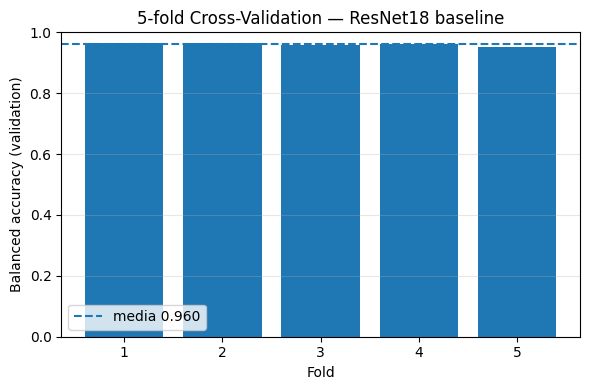

In [ ]:
# Grafico: balanced accuracy per fold + linea della media
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar([str(f) for f in folds_done], balaccs)
plt.axhline(balaccs.mean(), linestyle='--', label=f'media {balaccs.mean():.3f}')
plt.ylim(0, 1)
plt.xlabel('Fold'); plt.ylabel('Balanced accuracy (validation)')
plt.title('5-fold Cross-Validation — ResNet18 baseline')
plt.legend(); plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cv_balacc_per_fold.png', dpi=150)
plt.show()
